# Трансферное обучение для классификации джетов в физике высоких энергий: FCNN

В качестве бейзлайн-модели используется полносвязная нейронная сеть (FCNN)
с применением knowledge distillation в схеме Teacher–Student.
Данная модель не использует графовое представление данных
и служит улучшенной точкой отсчета для сравнения с графовыми архитектурами.


## Предпосылки

Эксперименты на ускорителях частиц в ЦЕРН генерируют огромные объемы данных, с обработкой которых традиционные методы анализа без использования машинного обучения зачастую не справляются. Часть этих экспериментов посвящена изучению джетов - потоков вторичных частиц, возникающих при высокоэнергетических столкновениях первичных частиц. Для каждого джета требуется как можно быстрее определить, какая первичная частица привела к его образованию, чтобы принять решение о сохранении соответствующего события для дальнейшего анализа.

Потоки данных, получаемые в таких экспериментах, содержат информацию высокого качества, хранение которой требует значительных ресурсов. В связи с этим возникает следующий вопрос: **возможно ли обучить «student»-модель, принимающую на вход данные джетов пониженного качества, предсказывать первичную частицу с той же точностью, что и более сложная «teacher»-модель, обученная на данных высокого качества?** В более простой формулировке задача сводится к бинарной классификации: определить, был ли джет инициирован топ-кварком (`label: 1`) или относится к фоновым событиям (`label: 0`).

В работе используется набор данных [ATLAS Top Tagging Open Data Set](https://opendata.cern.ch/record/15013), представляющий собой симулированные события с джетами, подготовленные коллаборацией ATLAS.


In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.optim as optim
from helper import *
from preprocess import *
from torch.utils.data import DataLoader
from visualize import *

warnings.filterwarnings("ignore")  # pesky divide-by-zero errors

sns.set_theme()
plt.style.use("seaborn-v0_8")

In [2]:
# Initialize some global hyperparameters

NH = 2  # number of hidden layers for the full (teacher) model: 5
NE = 35  # number of epochs
LR = 1.2e-5  # learning rate: 1.2e-5
BATCH_SZ = 32  # batch size: 250
MAX_ITEMS = 50000  # maximum number of elements to consider (input size): 3,000,000
MAX_CONSTITS = 80  # maximum number of constituent elements per jet: 80

# REDUCED_CONSTITS = 80  # number of constituent elements for the Student network to consider: 40
# NOISE_STD = 5e3  # noise standard deviation for the diffusion: 5e3
# DIFFUSE_AXES = ['fjet_clus_E', 'fjet_clus_pt']  # Which axis/axes to apply diffusion to

ALPHA = 0.5  # alpha parameter for knowledge transfer: 0.8
TEMP = 2.0  # temperature parameter for knowledge transfer: 2.0

#### Визуализация входных данных

На первом этапе загрузим данные и рассмотрим их структуру. Набор данных содержит признаки трех уровней: `jet` (агрегированные характеристики всего джета), `constituents` (признаки отдельных частиц) и `high-level` (заранее сконструированные признаки из работ ATLAS). В рамках проекта используются признаки уровня `constituents`, так как они содержат наиболее информативное описание структуры джета для задачи классификации.

> Процедура подробно описана в `notebooks/01_eda_atlas_jets.ipynb`, а графики приведены в `results/eda.ipynb`.

Используемые признаки содержат важную информацию о джетах, такую как, например **масса, энергия, импульс**.

При проведении EDA, мы смотрели на распределения массы джета, псевдобыстроты, азимутального угла и энергии по классам. Даже при визуальном анализе можно было заметить некоторые различия между классами.

Однако, **на уровне конституентов различать сигнал и фон становится значительно сложнее (даже визуально)**. Используем нейронную сеть для выявления этих тонких различий и помощи в решении задачи классификации.

### Preprocessing

Сырые данные на уровне конституентов непригодны для непосредственного обучения глубокой нейронной сети. Во-первых, необходимо учесть широкий динамический диапазон значений энергии и импульса. Во-вторых, признаки $\eta$ и $\phi$ исходном виде содержат ограниченное количество информации и требуют преобразования с использованием физически обоснованных формул.

Данная предобработка выполняется с помощью функции `preprocess.constituent_preprocess`, адаптированной из кода, предоставленного коллаборацией ATLAS.

In [6]:
# # First, split the teacher data in half -- half HQ data, half LQ data
# teacher_hq = teacher_data[:int(MAX_ITEMS/2)]
# teacher_lq = teacher_data[int(MAX_ITEMS/2):]

# # Pass the teacher_lq array throught the same data degradation steps as the student's data will be
# teacher_lq = diffuse(teacher_lq, teacher_features, noise_std=NOISE_STD,
#                              apply_features=DIFFUSE_AXES,
#                             )

# # Preprocess LQ data
# teacher_lq, _ = constituent_preprocess(teacher_lq, teacher_features, max_constits=REDUCED_CONSTITS)
# teacher_lq = add_constits(teacher_lq, target_shape=MAX_CONSTITS)  # padding

# # Preprocess HQ data
# teacher_hq, _ = constituent_preprocess(teacher_hq, teacher_features, max_constits=REDUCED_CONSTITS)

# # Finally, stitch them pack together
# teacher_data = np.concatenate((teacher_hq, teacher_lq))

# print("Preprocessed teacher data shape:", teacher_data.shape)
# print("Preprocessed features:", teacher_features)


In [7]:
teacher_data, teacher_features = constituent_preprocess(
    teacher_data, teacher_features, max_constits=MAX_CONSTITS
)
student_data, _ = constituent_preprocess(student_data, student_features, max_constits=MAX_CONSTITS)

print("Preprocessed teacher data shape:", teacher_data.shape)
print("Preprocessed features:", teacher_features)

Preprocessed teacher data shape: (50000, 80, 7)
Preprocessed features: ['delta_eta' 'delta_phi' 'log_pt' 'log_E' 'lognorm_pt' 'lognorm_E' 'R']


In [8]:
# plot_preprocessed_1D_distributions(pre_cons_data, cons_labels, pre_cons_features, nbins=40)

На этом этапе представление данных становится менее интуитивным, однако основная идея заключается в том, что такие преобразованные признаки должны помочь нейронной сети обучаться более эффективно и достигать лучшего качества.

### Этап 1: Transfer Learning с использованием FCNN (baseline)

В качестве первого шага необходимо проверить корректность реализации transfer learning. Для этого обучается Teacher-модель FCNN на данных высокого качества из набора ATLAS. Затем данные искусственно ухудшаются с помощью диффузии и downsampling, после чего знания Teacher-модели передаются Student-модели FCNN. Student обучается на данных пониженного качества, а качество обеих моделей сравнивается между собой.

Сначала обучим Teacher-модель FCNN на данных уровня конституентов. Для этого в ноутбуке определяется функция обучающего цикла, так как она использует большое количество глобальных параметров.

In [9]:
from model import run_model, train_with_distillation


def training_loop(
    model,
    device,
    data,
    labels,
    weights,
    plot_confusion=False,
    teacher_model=None,
    alpha=ALPHA,
    temp=TEMP,
):
    """
    Run the whole training loop on the model given data, labels, and weights

    References a lot of global parameters
    """
    model.to(device)
    criterion = torch.nn.CrossEntropyLoss(reduction="none")
    optimizer = optim.Adam(model.parameters(), lr=LR)

    # Data preparation
    train_set, val_set, test_set = standardize_split(
        data, labels, weights, train_split=0.7, val_split=0.15
    )
    train_loader = DataLoader(train_set, batch_size=BATCH_SZ, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SZ, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=BATCH_SZ, shuffle=True)

    loss_list, acc_list = [], []
    val_loss_list, val_acc_list = [], []

    t0 = time.time()
    for epoch in range(1, NE + 1):
        # training -- with knowledge distillation
        if teacher_model:
            loss, acc = train_with_distillation(
                model,
                teacher_model,
                "fcnn",
                train_loader,
                criterion,
                optimizer,
                device,
                alpha=alpha,
                temperature=temp,
            )

        # training -- without knowledge distillation
        else:
            loss, acc = run_model(
                model, "fcnn", device, train_loader, criterion, optimizer=optimizer, train=True
            )

        loss_list.append(loss)
        acc_list.append(acc)

        # validation
        val_loss, val_acc, _, _ = run_model(
            model, "fcnn", device, val_loader, criterion, train=False
        )
        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)

        if epoch % 5 == 0:
            print(
                f"E {epoch:02d} -- Train loss: {loss:.3f} -- Train acc: {acc:.3f} -- "
                + f"Val loss: {val_loss:.3f} -- Val acc: {val_acc:.3f} -- t elapsed: {time_elapsed(t0,time.time())} mins"
            )

    # Testing on unseen data...
    inf_t0 = time.time()
    test_loss, test_acc, fpr, tpr = run_model(
        model,
        "fcnn",
        device,
        test_loader,
        criterion,
        train=False,
    )
    print(
        f"Inference time on test set containing {int(len(test_loader)*BATCH_SZ)} elements:",
        time.time() - inf_t0,
        "sec.",
    )

    # And finally plot the confusion matrix if desired
    if plot_confusion:
        true = []
        pred = []
        for d, l, w in test_set:
            d = d.unsqueeze(0)
            true.append(l.item())
            p = np.argmax(model(d.to(device)).cpu().detach().numpy())
            pred.append(p)

        plot_confusion_matrices(true, pred, "")

    return loss_list, acc_list, val_loss_list, val_acc_list, test_loss, test_acc, fpr, tpr

In [10]:
from model import JetFCNN

# model initialization
num_features = int(teacher_data.shape[1] * teacher_data.shape[2])
teacher_fcnn = JetFCNN(num_features=num_features, num_hidden_layers=NH)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "\n")

# Train and test the model
unpackable1 = training_loop(teacher_fcnn, device, teacher_data, teacher_labels, teacher_weights)

# Unpack results
(
    teach_trainloss,
    teach_trainacc,
    teach_valloss,
    teach_valacc,
    teach_testloss,
    teach_testacc,
    fpr_teacher,
    tpr_teacher,
) = unpackable1

Device: cpu 

E 05 -- Train loss: 0.594 -- Train acc: 0.698 -- Val loss: 0.555 -- Val acc: 0.737 -- t elapsed: 0.64 mins
E 10 -- Train loss: 0.552 -- Train acc: 0.726 -- Val loss: 0.533 -- Val acc: 0.757 -- t elapsed: 1.26 mins
E 15 -- Train loss: 0.517 -- Train acc: 0.748 -- Val loss: 0.521 -- Val acc: 0.769 -- t elapsed: 1.96 mins
E 20 -- Train loss: 0.494 -- Train acc: 0.761 -- Val loss: 0.511 -- Val acc: 0.773 -- t elapsed: 2.61 mins
E 25 -- Train loss: 0.472 -- Train acc: 0.773 -- Val loss: 0.502 -- Val acc: 0.779 -- t elapsed: 3.33 mins
E 30 -- Train loss: 0.457 -- Train acc: 0.783 -- Val loss: 0.491 -- Val acc: 0.782 -- t elapsed: 4.0 mins
E 35 -- Train loss: 0.442 -- Train acc: 0.794 -- Val loss: 0.488 -- Val acc: 0.783 -- t elapsed: 4.71 mins
Inference time on test set containing 7520 elements: 0.5326888561248779 sec.


#### Результаты

Teacher FCNN


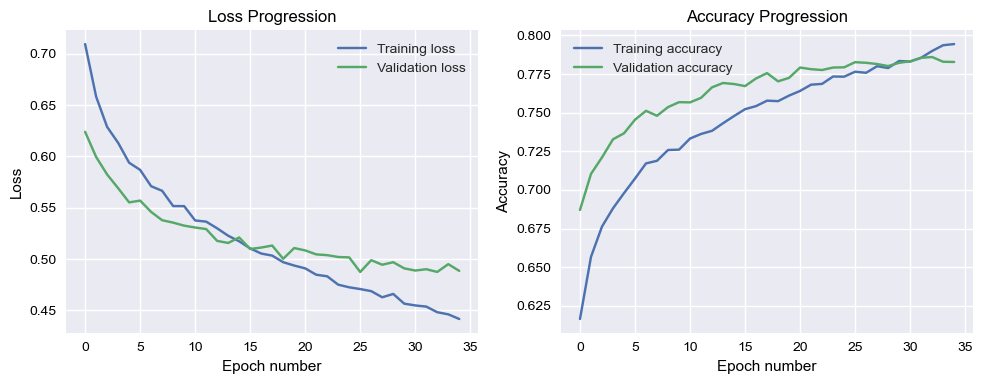

Final test loss: 0.4826	 Final test acc: 0.7760


In [11]:
print("Teacher FCNN")

plot_loss_and_accuracy(
    teach_trainloss,
    teach_valloss,
    teach_trainacc,
    teach_valacc,
    # transparent=True,
    # save_path="./teacher_fcnn.png",
)

print(f"Final test loss: {teach_testloss:.4f}\t Final test acc: {teach_testacc:.4f}")

### Модель Студента

Далее переходим к обучению более компактной Student-модели.

In [12]:
from model import StudentFCNN

# model initialization
student_no_distill = StudentFCNN(num_features=num_features).to(device)

# Run the training loop
unpackable2 = training_loop(
    student_no_distill, device, student_data, student_labels, student_weights
)

# Unpack the results
(
    stu_trainloss,
    stu_trainacc,
    stu_valloss,
    stu_valacc,
    stu_testloss,
    stu_testacc,
    fpr_student,
    tpr_student,
) = unpackable2

E 05 -- Train loss: 0.659 -- Train acc: 0.634 -- Val loss: 0.612 -- Val acc: 0.665 -- t elapsed: 0.13 mins
E 10 -- Train loss: 0.625 -- Train acc: 0.671 -- Val loss: 0.584 -- Val acc: 0.704 -- t elapsed: 0.26 mins
E 15 -- Train loss: 0.603 -- Train acc: 0.689 -- Val loss: 0.564 -- Val acc: 0.715 -- t elapsed: 0.4 mins
E 20 -- Train loss: 0.586 -- Train acc: 0.704 -- Val loss: 0.544 -- Val acc: 0.724 -- t elapsed: 0.53 mins
E 25 -- Train loss: 0.565 -- Train acc: 0.716 -- Val loss: 0.530 -- Val acc: 0.735 -- t elapsed: 0.66 mins
E 30 -- Train loss: 0.556 -- Train acc: 0.724 -- Val loss: 0.518 -- Val acc: 0.742 -- t elapsed: 0.79 mins
E 35 -- Train loss: 0.548 -- Train acc: 0.729 -- Val loss: 0.509 -- Val acc: 0.747 -- t elapsed: 0.92 mins
Inference time on test set containing 7520 elements: 0.09670114517211914 sec.


Student FCNN without knowledge distillation


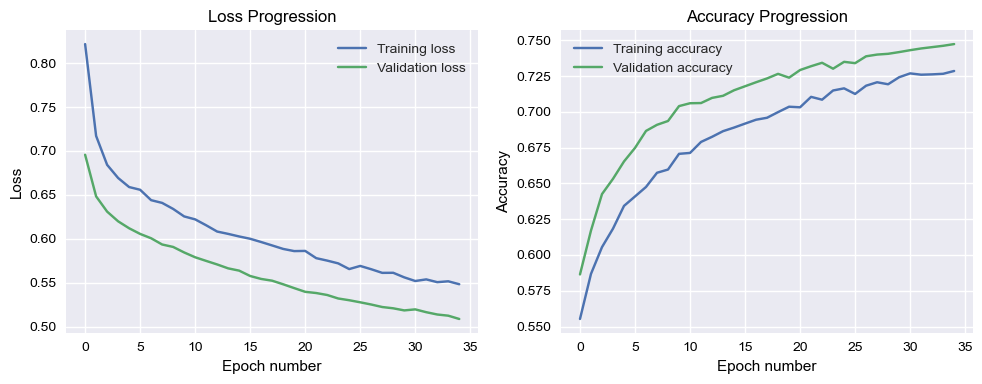

Final test loss: 0.5275	 Final test acc: 0.7433


In [13]:
print("Student FCNN without knowledge distillation")

plot_loss_and_accuracy(
    stu_trainloss,
    stu_valloss,
    stu_trainacc,
    stu_valacc,
    # transparent=True,
    # save_path="./student_fcnn_nodistill.png",
)
print(f"Final test loss: {stu_testloss:.4f}\t Final test acc: {stu_testacc:.4f}")

Видно, что качество модели на диффузированных данных немного ухудшается. Более того, модель начинает немного переобучаться, так как данные становятся слишком шумными и сложными для интерпретации. Попробуем проверить, сможет ли перенос знаний улучшить ситуацию.

### Перенос знаний от Teacher- к Student-модели FCNN

In [14]:
# model initialization
student_fcnn = StudentFCNN(num_features=num_features).to(device)

# run the training loop
unpackable3 = training_loop(
    student_fcnn,
    device,
    student_data,
    student_labels,
    student_weights,
    teacher_model=teacher_fcnn,
    #                             alpha=0.5, temp=3,
)

# unpack results
(
    dist_trainloss,
    dist_trainacc,
    dist_valloss,
    dist_valacc,
    dist_testloss,
    dist_testacc,
    fpr_distill,
    tpr_distill,
) = unpackable3

E 05 -- Train loss: 0.472 -- Train acc: 0.685 -- Val loss: 0.597 -- Val acc: 0.721 -- t elapsed: 0.31 mins
E 10 -- Train loss: 0.424 -- Train acc: 0.709 -- Val loss: 0.562 -- Val acc: 0.744 -- t elapsed: 0.7 mins
E 15 -- Train loss: 0.391 -- Train acc: 0.723 -- Val loss: 0.547 -- Val acc: 0.752 -- t elapsed: 1.05 mins
E 20 -- Train loss: 0.370 -- Train acc: 0.730 -- Val loss: 0.521 -- Val acc: 0.764 -- t elapsed: 1.5 mins
E 25 -- Train loss: 0.356 -- Train acc: 0.739 -- Val loss: 0.507 -- Val acc: 0.768 -- t elapsed: 1.87 mins
E 30 -- Train loss: 0.348 -- Train acc: 0.741 -- Val loss: 0.501 -- Val acc: 0.774 -- t elapsed: 2.2 mins
E 35 -- Train loss: 0.336 -- Train acc: 0.745 -- Val loss: 0.494 -- Val acc: 0.776 -- t elapsed: 2.6 mins
Inference time on test set containing 7520 elements: 0.1035158634185791 sec.


Student FCNN with knowledge distillation


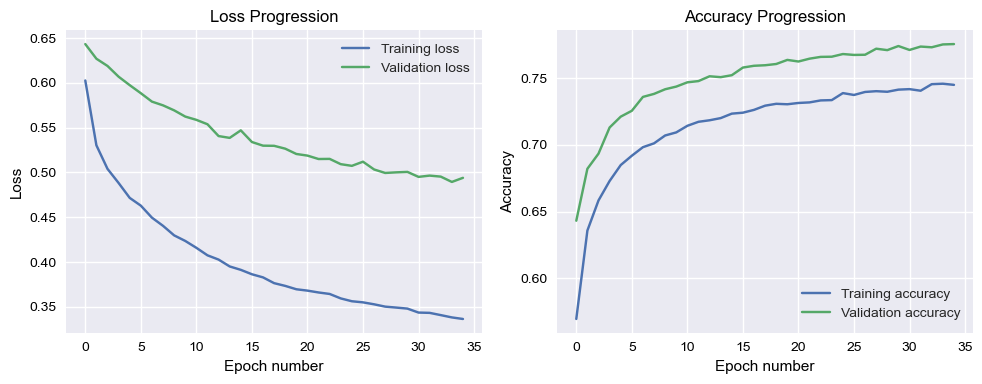

Final test loss: 0.5032	 Final test acc: 0.7663


In [15]:
print("Student FCNN with knowledge distillation")

plot_loss_and_accuracy(
    dist_trainloss,
    dist_valloss,
    dist_trainacc,
    dist_valacc,
    # transparent=True,
    # save_path="./student_fcnn_withdistill.png",
)

print(f"Final test loss: {dist_testloss:.4f}\t Final test acc: {dist_testacc:.4f}")

### Визуализация ROC-кривых

В завершение визуализируем ROC-кривые для следующих моделей:

1. Teacher-модель, обученная на данных высокого качества;
2. Student-модель, обученная на данных пониженного качества без дистилляции;
3. Student-модель, обученная на данных пониженного качества с применением knowledge distillation.


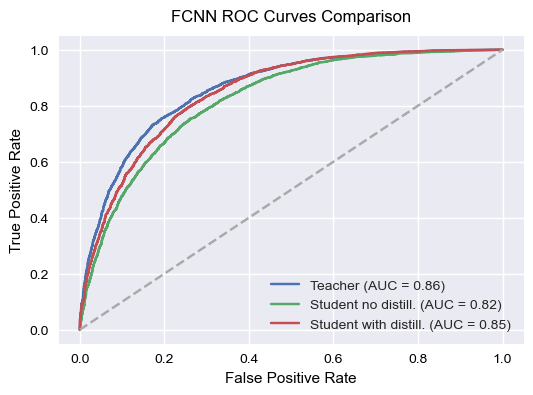

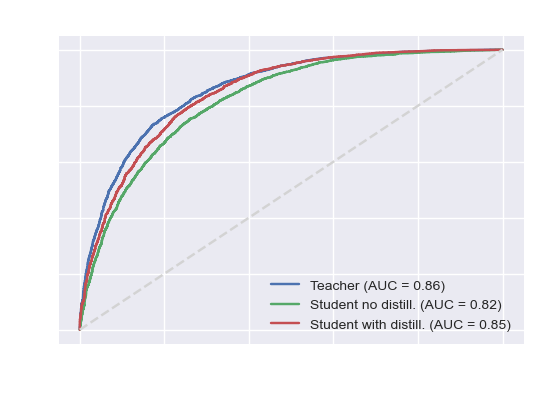

In [16]:
plot_roc(
    fpr_teacher,
    tpr_teacher,
    fpr_student,
    tpr_student,
    fpr_distill,
    tpr_distill,
    model_name="FCNN",
    transparent=False,
    #  save_path="./FCNN_ROC_small.png"
)

plot_roc(
    fpr_teacher,
    tpr_teacher,
    fpr_student,
    tpr_student,
    fpr_distill,
    tpr_distill,
    model_name="FCNN",
    transparent=True,
    #  save_path="./FCNN_ROC_small_transparent.png"
)